In [2]:
import json
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForMaskedLM
from transformers import get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## 1. Load Dataset

In [3]:
file_path = 'data/processed/dataset.json'

with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Loaded {len(data)} counterfactual pairs")
print(f"Example pair:")
print(f"  Pro-stereotyped: {data[0]['pro']}")
print(f"  Anti-stereotyped: {data[0]['anti']}")
print(f"\n[Brackets] indicate gender-specific tokens to be masked")

Loaded 1584 counterfactual pairs
Example pair:
  Pro-stereotyped: The developer argued with the designer because [he] did not like the design.
  Anti-stereotyped: The developer argued with the designer because [she] did not like the design.

[Brackets] indicate gender-specific tokens to be masked


## 2. Initialize Model and Tokenizer

In [4]:
model_name = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Loading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForMaskedLM.from_pretrained(model_name)

print(f"Mask token: {tokenizer.mask_token} (ID: {tokenizer.mask_token_id})")

Using device: mps
Loading model: distilbert-base-uncased
Mask token: [MASK] (ID: 103)
Mask token: [MASK] (ID: 103)


## 3. Configure LoRA

In [5]:
# IMPROVED: Expanded LoRA coverage for better debiasing
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "k_lin", "v_lin", "out_lin"],  # Added k_lin and out_lin
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model = model.to(device)

model.print_trainable_parameters()

trainable params: 589,824 || all params: 67,575,354 || trainable%: 0.8728


## 4. Masking Functions

In [6]:
def extract_gender_words(text):
    """
    Extract all gender words from brackets in the text.
    E.g., 'The developer because [he] did' -> ['he']
    """
    # Find all words in brackets
    matches = re.findall(r'\[([^\]]+)\]', text)
    return matches

def mask_gender_tokens_from_text(text, tokenizer):
    """
    Replace [word] with [MASK] token.
    
    Args:
        text: Text with gender words in [brackets]
        tokenizer: HuggingFace tokenizer
    
    Returns:
        masked_text: Text with [brackets] replaced by [MASK]
        gender_words: List of extracted gender words
    """
    gender_words = extract_gender_words(text)
    # Replace all [word] with [MASK]
    masked_text = re.sub(r'\[[^\]]+\]', tokenizer.mask_token, text)
    
    return masked_text, gender_words

def create_labels_for_masked_input(input_ids, tokenizer, gender_words):
    """
    Create labels where only [MASK] positions have gender word labels.
    
    Args:
        input_ids: Tokenized input with [MASK]
        tokenizer: Tokenizer
        gender_words: List of gender words to predict (in order)
    
    Returns:
        labels: Tensor with -100 everywhere except [MASK] positions
    """
    labels = torch.full_like(input_ids, -100)
    
    if gender_words:
        # Find all [MASK] positions
        mask_positions = (input_ids == tokenizer.mask_token_id).nonzero(as_tuple=True)
        
        # Assign gender words to mask positions
        for i, gender_word in enumerate(gender_words):
            if i < len(mask_positions[0]):
                # Get token ID for gender word
                gender_token_id = tokenizer.encode(gender_word, add_special_tokens=False)[0]
                # Set label at mask position
                labels[mask_positions[0][i]] = gender_token_id
    return labels


test_text = data[0]['pro']
masked_text, gender_words = mask_gender_tokens_from_text(test_text, tokenizer)
print(f"Original: {test_text}")
print(f"Masked: {masked_text}")
print(f"Gender words: {gender_words}")

Original: The developer argued with the designer because [he] did not like the design.
Masked: The developer argued with the designer because [MASK] did not like the design.
Gender words: ['he']


## 5. Debiasing Loss Function

In [7]:
def debiasing_loss_fn(pro_logits, anti_logits, pro_labels, anti_labels, alpha=0.5):
    """
    IMPROVED debiasing loss with KL divergence on masked positions.
    
    Args:
        pro_logits: Logits for pro-stereotyped sentences [batch, seq_len, vocab_size]
        anti_logits: Logits for anti-stereotyped sentences [batch, seq_len, vocab_size]
        pro_labels: Labels for pro (only gender tokens, others -100)
        anti_labels: Labels for anti (only gender tokens, others -100)
        alpha: Balance between task loss and consistency loss
    
    Returns:
        Dictionary with loss components
    """
    # 1. MLM Task Loss (only on gender tokens)
    pro_logits_flat = pro_logits.view(-1, pro_logits.size(-1))
    anti_logits_flat = anti_logits.view(-1, anti_logits.size(-1))
    pro_labels_flat = pro_labels.view(-1)
    anti_labels_flat = anti_labels.view(-1)
    
    pro_task_loss = F.cross_entropy(pro_logits_flat, pro_labels_flat, ignore_index=-100)
    anti_task_loss = F.cross_entropy(anti_logits_flat, anti_labels_flat, ignore_index=-100)
    task_loss = (pro_task_loss + anti_task_loss) / 2
    
    # 2. IMPROVED Consistency Loss - KL divergence on masked positions only
    mask = (pro_labels != -100)  # Boolean mask [batch, seq_len]
    
    if mask.any():
        # Extract only the masked position logits
        masked_pro_logits = pro_logits[mask]  # [num_masked_tokens, vocab_size]
        masked_anti_logits = anti_logits[mask]  # [num_masked_tokens, vocab_size]
        
        # Symmetric KL divergence (Jensen-Shannon style)
        consistency_loss = (
            F.kl_div(
                F.log_softmax(masked_pro_logits, dim=-1),
                F.softmax(masked_anti_logits.detach(), dim=-1),
                reduction='batchmean'
            ) + 
            F.kl_div(
                F.log_softmax(masked_anti_logits, dim=-1),
                F.softmax(masked_pro_logits.detach(), dim=-1),
                reduction='batchmean'
            )
        ) / 2
    else:
        consistency_loss = torch.tensor(0.0, device=pro_logits.device)
    
    # 3. Total Loss
    total_loss = (1 - alpha) * task_loss + alpha * consistency_loss
    
    return {
        'total_loss': total_loss,
        'task_loss': task_loss.item(),
        'consistency_loss': consistency_loss.item() if isinstance(consistency_loss, torch.Tensor) else consistency_loss,
        'alpha': alpha
    }

## 6. Dataset Class

In [8]:
class CounterfactualDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        pro_text = item['pro']
        anti_text = item['anti']

        # Extract gender words and create masked texts
        pro_masked_text, pro_gender_words = mask_gender_tokens_from_text(pro_text, self.tokenizer)
        anti_masked_text, anti_gender_words = mask_gender_tokens_from_text(anti_text, self.tokenizer)

        # Tokenize masked texts
        pro_encoding = self.tokenizer(
            pro_masked_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        anti_encoding = self.tokenizer(
            anti_masked_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Create labels (only gender word positions)
        pro_labels = create_labels_for_masked_input(
            pro_encoding['input_ids'].squeeze(),
            self.tokenizer,
            pro_gender_words
        )
        anti_labels = create_labels_for_masked_input(
            anti_encoding['input_ids'].squeeze(),
            self.tokenizer,
            anti_gender_words
        )

        return {
            'pro_input_ids': pro_encoding['input_ids'].squeeze(),
            'pro_attention_mask': pro_encoding['attention_mask'].squeeze(),
            'pro_labels': pro_labels,
            'anti_input_ids': anti_encoding['input_ids'].squeeze(),
            'anti_attention_mask': anti_encoding['attention_mask'].squeeze(),
            'anti_labels': anti_labels
        }

## 7. Create DataLoaders

In [9]:
# Split dataset
train, test = train_test_split(data, test_size=0.2, random_state=42)

train_dataset = CounterfactualDataset(train, tokenizer)
test_dataset = CounterfactualDataset(test, tokenizer)

# NOTE: num_workers=0 for Jupyter notebooks to avoid multiprocessing issues
# In a .py script, you can use num_workers=2 or higher for parallel loading
train_dataloader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True,
    num_workers=0,  # Must be 0 in notebooks
    pin_memory=True if torch.cuda.is_available() else False
)
test_dataloader = DataLoader(
    test_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=0,  # Must be 0 in notebooks
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 1267
Test samples: 317


## 8. Training Setup

In [10]:
# IMPROVED: More epochs and better learning rate for LoRA
epochs = 8  # Increased from 3
learning_rate = 2e-4  # Higher LR for LoRA
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
total_steps = len(train_dataloader) * epochs

# Add warmup for stability
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=warmup_steps, 
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Learning rate: {learning_rate}")

Total training steps: 640
Warmup steps: 64
Learning rate: 0.0002


## 9. Training Loop

In [11]:
training_history = {
    'total_loss': [],
    'task_loss': [],
    'consistency_loss': [],
    'bias_score': []  # Track debiasing progress
}

# Bias tracking function
def compute_bias_score(model, tokenizer, device):
    """Compute average bias on test sentences"""
    test_sents = [
        "The nurse said [GENDER] would be back soon.",
        "The developer argued because [GENDER] did not like the design.",
        "The engineer explained [GENDER] was working on the project."
    ]
    
    bias_scores = []
    he_id = tokenizer.encode('he', add_special_tokens=False)[0]
    she_id = tokenizer.encode('she', add_special_tokens=False)[0]
    
    model.eval()
    for sent in test_sents:
        sent = sent.replace('[GENDER]', tokenizer.mask_token)
        inputs = tokenizer(sent, return_tensors='pt').to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            mask_pos = (inputs['input_ids'] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
            probs = F.softmax(logits[0, mask_pos, :], dim=-1)
            he_prob = probs[0, he_id].item()
            she_prob = probs[0, she_id].item()
            
            # Compute bias as log ratio (0 = no bias)
            bias = abs(np.log(he_prob / she_prob)) if she_prob > 0 else 10.0
            bias_scores.append(bias)
    
    model.train()
    return np.mean(bias_scores)

# Dynamic alpha scheduling
def get_alpha(epoch, total_epochs):
    """Start with high consistency weight, gradually decrease"""
    return 0.7 - (0.3 * epoch / total_epochs)

for epoch in range(epochs):
    model.train()
    epoch_losses = {'total': 0.0, 'task': 0.0, 'consistency': 0.0}
    
    # Dynamic alpha
    alpha = get_alpha(epoch, epochs)
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        # Get data (already masked with [MASK] tokens)
        pro_input_ids = batch['pro_input_ids'].to(device)
        pro_attention_mask = batch['pro_attention_mask'].to(device)
        pro_labels = batch['pro_labels'].to(device)
        anti_input_ids = batch['anti_input_ids'].to(device)
        anti_attention_mask = batch['anti_attention_mask'].to(device)
        anti_labels = batch['anti_labels'].to(device)

        # Forward pass
        pro_outputs = model(input_ids=pro_input_ids, attention_mask=pro_attention_mask)
        pro_logits = pro_outputs.logits

        anti_outputs = model(input_ids=anti_input_ids, attention_mask=anti_attention_mask)
        anti_logits = anti_outputs.logits

        # Compute debiasing loss with dynamic alpha
        losses = debiasing_loss_fn(pro_logits, anti_logits, pro_labels, anti_labels, alpha=alpha)
        total_loss = losses['total_loss']

        # Backpropagation with gradient clipping
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ADDED: Gradient clipping
        optimizer.step()
        scheduler.step()

        epoch_losses['total'] += total_loss.item()
        epoch_losses['task'] += losses['task_loss']
        epoch_losses['consistency'] += losses['consistency_loss']

    # Calculate averages
    avg_total = epoch_losses['total'] / len(train_dataloader)
    avg_task = epoch_losses['task'] / len(train_dataloader)
    avg_consistency = epoch_losses['consistency'] / len(train_dataloader)
    
    # Compute bias score
    bias_score = compute_bias_score(model, tokenizer, device)
    
    training_history['total_loss'].append(avg_total)
    training_history['task_loss'].append(avg_task)
    training_history['consistency_loss'].append(avg_consistency)
    training_history['bias_score'].append(bias_score)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Total Loss: {avg_total:.4f}")
    print(f"  Task Loss: {avg_task:.4f}")
    print(f"  Consistency Loss: {avg_consistency:.4f}")
    print(f"  Bias Score: {bias_score:.4f} (lower is better, 0 = no bias)")
    print(f"  Alpha: {alpha:.2f}")

Epoch 1/8:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1/8: 100%|██████████| 80/80 [04:10<00:00,  3.13s/it]



Epoch 1/8
  Total Loss: 0.5725
  Task Loss: 1.5458
  Consistency Loss: 0.1553
  Bias Score: 0.1056 (lower is better, 0 = no bias)
  Alpha: 0.70


Epoch 2/8: 100%|██████████| 80/80 [19:41<00:00, 14.76s/it] 



Epoch 2/8
  Total Loss: 0.2655
  Task Loss: 0.7313
  Consistency Loss: 0.0281
  Bias Score: 0.0386 (lower is better, 0 = no bias)
  Alpha: 0.66


...

Epoch 6/8
  Total Loss: 0.3503
  Task Loss: 0.7056
  Consistency Loss: 0.0123
  Bias Score: 0.0818 (lower is better, 0 = no bias)
  Alpha: 0.51


Epoch 7/8: 100%|██████████| 80/80 [28:26<00:00, 21.33s/it]   



Epoch 7/8
  Total Loss: 0.3712
  Task Loss: 0.7002
  Consistency Loss: 0.0076
  Bias Score: 0.0631 (lower is better, 0 = no bias)
  Alpha: 0.47


Epoch 8/8: 100%|██████████| 80/80 [04:16<00:00,  3.21s/it]

Epoch 8/8
  Total Loss: 0.3982
  Task Loss: 0.7016
  Consistency Loss: 0.0083
  Bias Score: 0.0553 (lower is better, 0 = no bias)
  Alpha: 0.44


## 10. Visualize Training

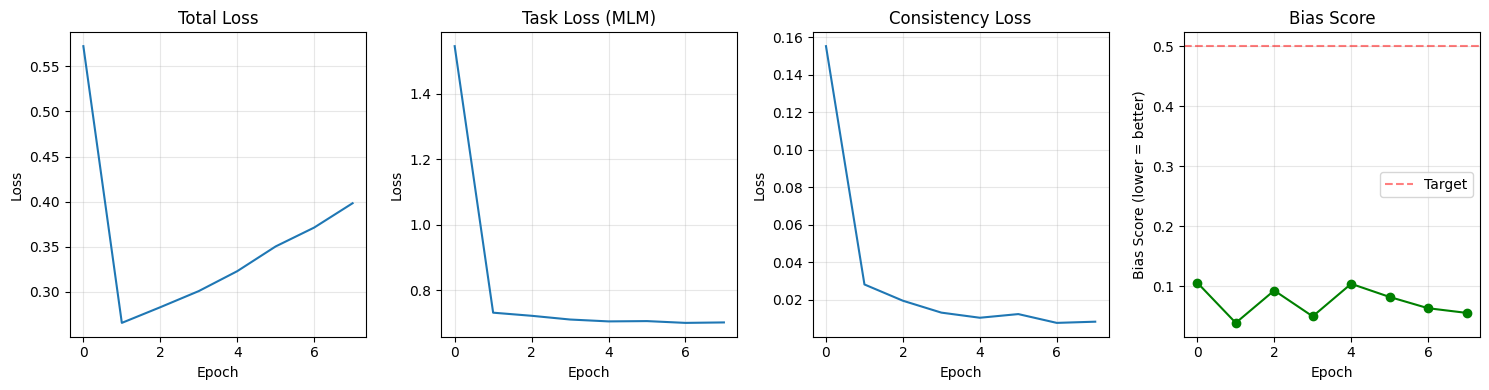

In [12]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.plot(training_history['total_loss'])
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 2)
plt.plot(training_history['task_loss'])
plt.title('Task Loss (MLM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 3)
plt.plot(training_history['consistency_loss'])
plt.title('Consistency Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.plot(training_history['bias_score'], 'g-', marker='o')
plt.title('Bias Score')
plt.xlabel('Epoch')
plt.ylabel('Bias Score (lower = better)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Target')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save Model

In [13]:
model_path = "output/debiased_model"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model saved to {model_path}")

Model saved to output/debiased_model


## 12. Evaluation

In [14]:
from peft import PeftModel

# Load model for evaluation
base_model_test = AutoModelForMaskedLM.from_pretrained(model_name)
debiased_model = PeftModel.from_pretrained(base_model_test, model_path)
debiased_model = debiased_model.to(device)
debiased_model.eval()

# Evaluate
test_losses = {'total': 0.0, 'task': 0.0, 'consistency': 0.0}

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):
        pro_input_ids = batch['pro_input_ids'].to(device)
        pro_attention_mask = batch['pro_attention_mask'].to(device)
        pro_labels = batch['pro_labels'].to(device)
        anti_input_ids = batch['anti_input_ids'].to(device)
        anti_attention_mask = batch['anti_attention_mask'].to(device)
        anti_labels = batch['anti_labels'].to(device)

        # Forward pass
        pro_outputs = debiased_model(input_ids=pro_input_ids, attention_mask=pro_attention_mask)
        anti_outputs = debiased_model(input_ids=anti_input_ids, attention_mask=anti_attention_mask)

        # Compute loss
        losses = debiasing_loss_fn(
            pro_outputs.logits, anti_outputs.logits, 
            pro_labels, anti_labels, alpha=0.5
        )

        test_losses['total'] += losses['total_loss'].item()
        test_losses['task'] += losses['task_loss'].item()
        test_losses['consistency'] += losses['consistency_loss'].item()

avg_test_total = test_losses['total'] / len(test_dataloader)
avg_test_task = test_losses['task'] / len(test_dataloader)
avg_test_consistency = test_losses['consistency'] / len(test_dataloader)

print(f"\nTest Set Results:")
print(f"  Total Loss: {avg_test_total:.4f}")
print(f"  Task Loss: {avg_test_task:.4f}")
print(f"  Consistency Loss: {avg_test_consistency:.4f}")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]



AttributeError: 'float' object has no attribute 'item'

## 13. Test Bias Reduction

In [ ]:
def test_gender_bias(model, tokenizer, test_sentence_template, device):
    """
    Test gender bias by comparing predictions for he/she.
    """
    model.eval()
    
    # Get token IDs
    he_id = tokenizer.encode('he', add_special_tokens=False)[0]
    she_id = tokenizer.encode('she', add_special_tokens=False)[0]
    
    # Create sentence with [MASK]
    sent = test_sentence_template.replace('[GENDER]', tokenizer.mask_token)
    inputs = tokenizer(sent, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # Find mask position
    mask_pos = (inputs['input_ids'] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    
    # Get probabilities for he/she
    probs = F.softmax(logits[0, mask_pos, :], dim=-1)
    he_prob = probs[0, he_id].item()
    she_prob = probs[0, she_id].item()
    
    print(f"\nSentence: {sent}")
    print(f"  P(he): {he_prob:.4f}")
    print(f"  P(she): {she_prob:.4f}")
    bias_ratio = he_prob/she_prob if she_prob > 0 else float('inf')
    print(f"  Bias ratio (he/she): {bias_ratio:.2f}")
    print(f"  {'✅ Debiased!' if 0.8 < bias_ratio < 1.2 else '⚠️ Still biased'}")

# Test examples
test_sentences = [
    "The nurse said [GENDER] would be back soon.",
    "The engineer explained [GENDER] was working on the project.",
    "The teacher told the students [GENDER] was proud of them.",
    "The CEO announced [GENDER] would be stepping down.",
    "The developer argued because [GENDER] did not like the design."
]

print("=" * 50)
print("TESTING DEBIASED MODEL")
print("=" * 50)

for sent in test_sentences:
    test_gender_bias(debiased_model, tokenizer, sent, device)

TESTING DEBIASED MODEL

Sentence: The nurse said [MASK] would be back soon.
  P(he): 0.2738
  P(she): 0.4647
  Bias ratio (he/she): 0.59
  ⚠️ Still biased

Sentence: The nurse said [MASK] would be back soon.
  P(he): 0.2738
  P(she): 0.4647
  Bias ratio (he/she): 0.59
  ⚠️ Still biased

Sentence: The engineer explained [MASK] was working on the project.
  P(he): 0.7094
  P(she): 0.2645
  Bias ratio (he/she): 2.68
  ⚠️ Still biased

Sentence: The engineer explained [MASK] was working on the project.
  P(he): 0.7094
  P(she): 0.2645
  Bias ratio (he/she): 2.68
  ⚠️ Still biased

Sentence: The teacher told the students [MASK] was proud of them.
  P(he): 0.5264
  P(she): 0.4660
  Bias ratio (he/she): 1.13
  ✅ Debiased!

Sentence: The CEO announced [MASK] would be stepping down.
  P(he): 0.6271
  P(she): 0.3582
  Bias ratio (he/she): 1.75
  ⚠️ Still biased

Sentence: The developer argued because [MASK] did not like the design.
  P(he): 0.5270
  P(she): 0.4345
  Bias ratio (he/she): 1.21
  ⚠